In [2]:
import os
import numpy as np

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten

In [3]:
#Fetch valid count from Folders

In [4]:
count = 0
base_path = r'C:\Users\DELL\Downloads\N-RDD2024 Testing and Validation Data\valid'
dirs = os.listdir(base_path)
print("Valid Folder:")
for dir in dirs:
    dir_path = os.path.join(base_path, dir) 
    if os.path.isdir(dir_path):
        files = os.listdir(dir_path)
        image_count = len([file for file in files if file.lower().endswith(('.jpg', '.png'))]) 
        print(f'{dir} Folder has {image_count} Images')
        count =count +len(files)
print('Images Folder has '+ str(count) + ' Images')

Valid Folder:
D00 Folder has 2201 Images
D10 Folder has 1244 Images
D20 Folder has 1135 Images
D30 Folder has 58 Images
D40 Folder has 438 Images
D50 Folder has 142 Images
D60 Folder has 728 Images
D70 Folder has 529 Images
D80 Folder has 157 Images
D90 Folder has 2 Images
Images Folder has 6634 Images


In [5]:
#Fetch test count from Folders

In [6]:
count = 0
base_path = r'C:\Users\DELL\Downloads\N-RDD2024 Testing and Validation Data\test'
dirs = os.listdir(base_path)
print("Test Folder:")
for dir in dirs:
    dir_path = os.path.join(base_path, dir) 
    if os.path.isdir(dir_path):
        files = os.listdir(dir_path)
        image_count = len([file for file in files if file.lower().endswith(('.jpg', '.png'))]) 
        count =count +len(files)
        print(f'{dir} Folder has {image_count} Images')
print('Images Folder has '+ str(count) + ' Images')

Test Folder:
D00 Folder has 8810 Images
D10 Folder has 5104 Images
D20 Folder has 4904 Images
D30 Folder has 168 Images
D40 Folder has 1849 Images
D50 Folder has 651 Images
D60 Folder has 2873 Images
D70 Folder has 2238 Images
D80 Folder has 569 Images
D90 Folder has 15 Images
Images Folder has 27181 Images


In [7]:
#Load Images into arrays as dataset(test)

In [8]:
base_dir = r'C:\Users\DELL\Downloads\N-RDD2024 Testing and Validation Data\test'
valbase_dir=r'C:\Users\DELL\Downloads\N-RDD2024 Testing and Validation Data\valid'
img_size=180
batch =32

In [9]:
train_ds= tf.keras.utils.image_dataset_from_directory( base_dir,
                                                      seed=123,
                                                      validation_split=0.2, 
                                                      subset = 'training',
                                                      batch_size=batch,
                                                      image_size=(img_size,img_size))

                                                      
val_ds= tf.keras.utils.image_dataset_from_directory( base_dir,
                                                      seed=123,
                                                      validation_split=0.2, 
                                                      subset = 'validation',
                                                      batch_size=batch,
                                                      image_size=(img_size,img_size))
                      

Found 27181 files belonging to 10 classes.
Using 21745 files for training.
Found 27181 files belonging to 10 classes.
Using 5436 files for validation.


In [10]:
road_defects = train_ds.class_names
road_defects

['D00', 'D10', 'D20', 'D30', 'D40', 'D50', 'D60', 'D70', 'D80', 'D90']

In [11]:
import matplotlib.pyplot as plt

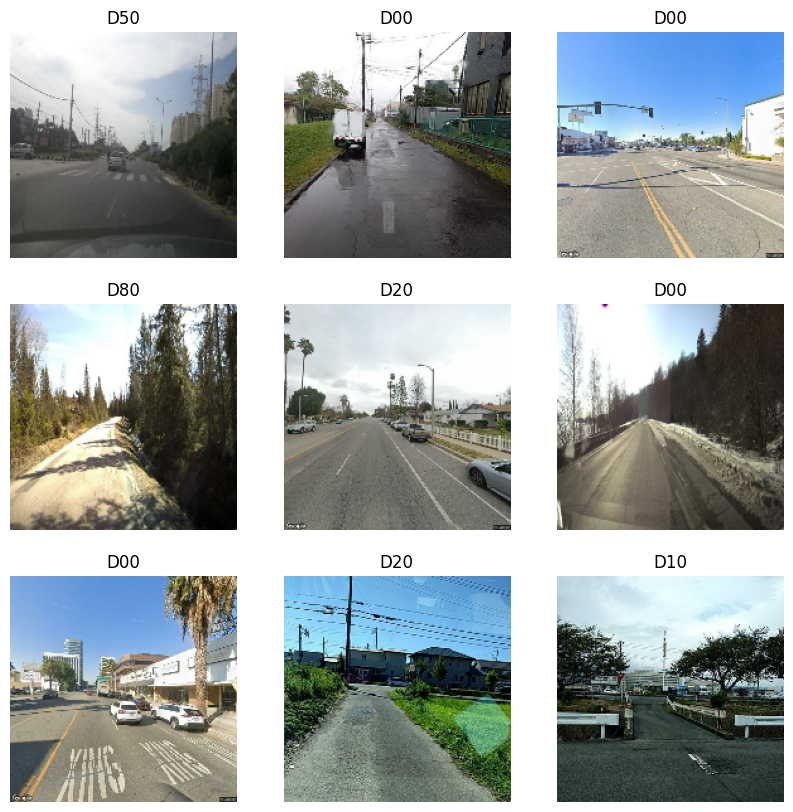

In [12]:
i=0
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(road_defects[labels[i]])
        plt.axis('off')

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

In [14]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)

In [15]:
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)

In [16]:
#Data Augmentation

In [18]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal",input_shape = (img_size,img_size,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

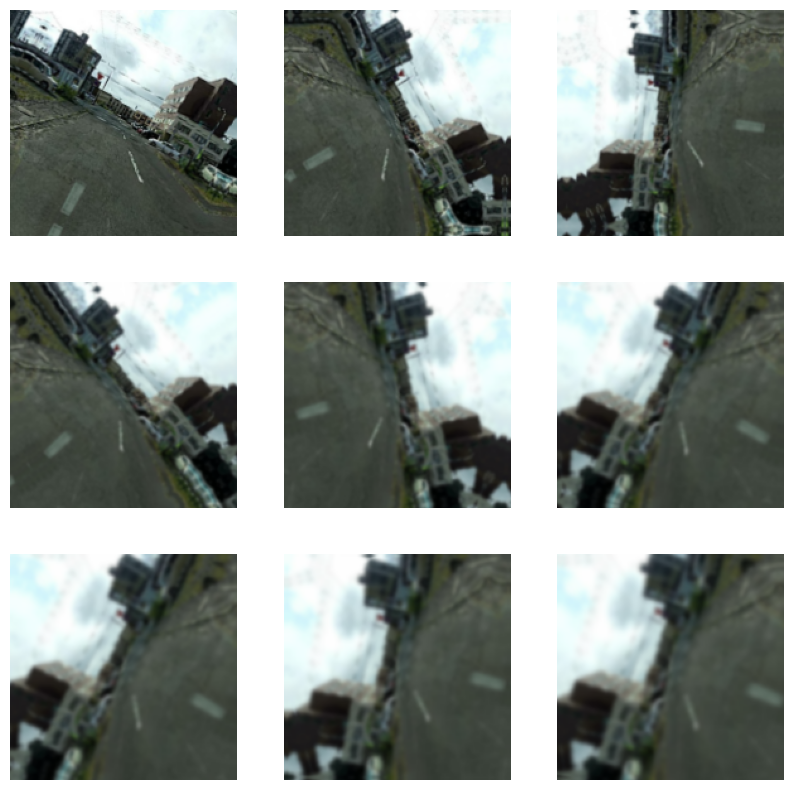

In [19]:
i=0
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        images =data_augmentation(images)
        plt.subplot(3,3, i+1)
        plt.imshow(images[0].numpy().astype('uint8'))
        plt.axis('off')

In [20]:
#Model Creation

In [21]:
model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    Conv2D(16, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10)
])

In [22]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)            │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,989,930 (15.22 MB)

 Trainable params: 3,989,930 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(train_ds, epochs=15, validation_data=val_ds)

Epoch 1/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 451s 655ms/step - accuracy: 0.3368 - loss: 1.8258 - val_accuracy: 0.3466 - val_loss: 1.7748
Epoch 2/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 622s 906ms/step - accuracy: 0.3667 - loss: 1.6897 - val_accuracy: 0.3675 - val_loss: 1.7116
Epoch 3/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 755s 1s/step - accuracy: 0.3773 - loss: 1.6605 - val_accuracy: 0.3755 - val_loss: 1.6579
Epoch 4/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 782s 1s/step - accuracy: 0.3770 - loss: 1.6383 - val_accuracy: 0.3767 - val_loss: 1.6537
Epoch 5/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 737s 1s/step - accuracy: 0.3864 - loss: 1.6233 - val_accuracy: 0.3692 - val_loss: 1.6820
Epoch 6/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 710s 1s/step - accuracy: 0.3803 - loss: 1.6139 - val_accuracy: 0.3688 - val_loss: 1.6426
Epoch 7/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 675s 993ms/step - accuracy: 0.3909 - loss: 1.5983 - val_accuracy: 0.3777 - val_loss: 1.6231
Epoch 8/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 649s 955ms/step - accuracy: 0.3833 - loss: 1.592

In [25]:
def classify_images(image_path):
    input_image = tf.keras.utils.load_img(image_path, target_size=(180,180))
    input_image_array= tf.keras.utils.img_to_array(input_image)
    input_image_exp_dim = tf.expand_dims(input_image_array,0)

    predictions = model.predict(input_image_exp_dim)
    result= tf.nn.softmax(predictions[0])
    outcome = 'The Image belongs to ' + road_defects[np.argmax(result)] + ' with a score of ' + str(np.max(result)*100)
    return outcome

In [29]:
model.save('road_damage_and_defect_recog_model_v3.h5')